# Notebook 4 — Best Model Generation and Evaluation
Project: **SVG-GPT: Scaling Transformer Language Models for Vector Graphics**

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Mount Google Drive and Create Folders

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/svg_gpt_scaling")

NOTEBOOK1_DIR = PROJECT_ROOT / "notebook1_preprocessing"
NOTEBOOK2_DIR = PROJECT_ROOT / "notebook2_standard_scaling"
NOTEBOOK4_DIR = PROJECT_ROOT / "notebook4_generation_eval"

CHECKPOINTS_DIR = NOTEBOOK4_DIR / "checkpoints"
GENERATIONS_DIR = NOTEBOOK4_DIR / "generations"
RENDERS_DIR = NOTEBOOK4_DIR / "renders"
METRICS_DIR = NOTEBOOK4_DIR / "metrics"
REPORT_ASSETS_DIR = NOTEBOOK4_DIR / "report_assets"
LOGS_DIR = NOTEBOOK4_DIR / "logs"

RAW_GENERATIONS_DIR = GENERATIONS_DIR / "raw_candidates"
RAW_RENDERS_DIR = RENDERS_DIR / "raw_candidates"
CURATED_GENERATIONS_DIR = GENERATIONS_DIR / "curated_report_samples"
CURATED_RENDERS_DIR = RENDERS_DIR / "curated_report_samples"

for d in [
    CHECKPOINTS_DIR, GENERATIONS_DIR, RENDERS_DIR, METRICS_DIR,
    REPORT_ASSETS_DIR, LOGS_DIR, RAW_GENERATIONS_DIR, RAW_RENDERS_DIR,
    CURATED_GENERATIONS_DIR, CURATED_RENDERS_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

print("Notebook 4 output folder:", NOTEBOOK4_DIR)

Notebook 4 output folder: /content/drive/MyDrive/svg_gpt_scaling/notebook4_generation_eval


## 2. Install and Import Dependencies

In [4]:
!pip -q install tokenizers pandas matplotlib tqdm numpy lxml cairosvg pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/46.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/75.6 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.8 MB/s eta 0:00:00


In [5]:
import os, re, io, json, math, time, random, gc, shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageDraw
from IPython.display import display, Image as IPyImage

import torch
import torch.nn as nn
from torch.nn import functional as F

from tokenizers import Tokenizer
from tqdm.auto import tqdm

from lxml import etree
import cairosvg

print("Imports complete.")

Imports complete.


## 3. Configuration

In [6]:
RANDOM_SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"

VOCAB_SIZE = 4096
BLOCK_SIZE = 512

MICRO_BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 4

# Continue training
ADDITIONAL_TRAIN_STEPS = 2500

CONTINUE_TRAIN_LR = 3e-4
MIN_LR_RATIO = 0.10
WARMUP_FRACTION = 0.03

EVAL_ITERS = 200
TEST_EVAL_ITERS = 300
LOG_INTERVAL = 50
EVAL_INTERVAL = 500

WEIGHT_DECAY = 0.1
BETA1 = 0.9
BETA2 = 0.95
GRAD_CLIP = 1.0

# Best model choice based on Parts 2 and 3.
SELECTED_MODEL_SOURCE = "standard_large"

# Revised generation settings.
NUM_UNCONDITIONAL_CANDIDATES = 80
PREFIX_CANDIDATES_PER_PREFIX = 16

TARGET_REPORT_UNCONDITIONAL = 12
TARGET_REPORT_PREFIX = 5

MAX_NEW_TOKENS = 900

# Low temperatures are repeated because they produced cleaner SVGs in the previous run.
UNCONDITIONAL_TEMPERATURE_SCHEDULE = [0.45, 0.50, 0.55, 0.60, 0.70, 0.80]
PREFIX_TEMPERATURE_SCHEDULE = [0.40, 0.45, 0.50, 0.55, 0.60]

TOP_K = 30
TOP_P = 0.90

RENDER_WIDTH = 256
RENDER_HEIGHT = 256

# Meaningfulness thresholds.
MIN_NON_BG_FRACTION = 0.01
MAX_DARK_FRACTION = 0.85
MAX_LIGHT_FRACTION = 0.98
MIN_PIXEL_STD = 5.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Device:", DEVICE)
print("dtype:", DTYPE)
print("Selected model:", SELECTED_MODEL_SOURCE)
print("Additional train steps:", ADDITIONAL_TRAIN_STEPS)
print("Unconditional candidates:", NUM_UNCONDITIONAL_CANDIDATES)
print("Prefix candidates per prefix:", PREFIX_CANDIDATES_PER_PREFIX)

Device: cuda
dtype: bfloat16
Selected model: standard_large
Additional train steps: 2500
Unconditional candidates: 80
Prefix candidates per prefix: 16


## 4. Load Tokenizer and Tokenized Data

In [7]:
preprocess_config_path = NOTEBOOK1_DIR / "preprocess_config_full.json"
if not preprocess_config_path.exists():
    raise FileNotFoundError(f"Missing {preprocess_config_path}")

with preprocess_config_path.open("r", encoding="utf-8") as f:
    preprocess_config = json.load(f)

tokenizer_path = Path(preprocess_config["tokenizer_path"])
train_bin_path = Path(preprocess_config["token_files"]["train"]["bin_path"])
val_bin_path = Path(preprocess_config["token_files"]["val"]["bin_path"])
test_bin_path = Path(preprocess_config["token_files"]["test"]["bin_path"])

tokenizer = Tokenizer.from_file(str(tokenizer_path))

train_tokens = np.memmap(train_bin_path, dtype=np.uint16, mode="r")
val_tokens = np.memmap(val_bin_path, dtype=np.uint16, mode="r")
test_tokens = np.memmap(test_bin_path, dtype=np.uint16, mode="r")

BOS_ID = tokenizer.token_to_id("<bos>")
EOS_ID = tokenizer.token_to_id("<eos>")
PAD_ID = tokenizer.token_to_id("<pad>")
UNK_ID = tokenizer.token_to_id("<unk>")

print("Tokenizer vocab size:", tokenizer.get_vocab_size())
print(f"Train tokens: {len(train_tokens):,}")
print(f"Val tokens:   {len(val_tokens):,}")
print(f"Test tokens:  {len(test_tokens):,}")
print("BOS/EOS/PAD/UNK:", BOS_ID, EOS_ID, PAD_ID, UNK_ID)

Tokenizer vocab size: 4096
Train tokens: 164,389,332
Val tokens:   1,657,304
Test tokens:  1,655,554
BOS/EOS/PAD/UNK: 1 2 0 3


## 5. Batch Loader

In [8]:
def get_batch(split: str, batch_size: int = MICRO_BATCH_SIZE, block_size: int = BLOCK_SIZE):
    if split == "train":
        data = train_tokens
    elif split == "val":
        data = val_tokens
    elif split == "test":
        data = test_tokens
    else:
        raise ValueError(split)

    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(np.array(data[i:i+block_size], dtype=np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(np.array(data[i+1:i+1+block_size], dtype=np.int64)) for i in ix])

    if DEVICE == "cuda":
        x = x.pin_memory().to(DEVICE, non_blocking=True)
        y = y.pin_memory().to(DEVICE, non_blocking=True)
    else:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

    return x, y

xb, yb = get_batch("train")
print(xb.shape, yb.shape)

torch.Size([16, 512]) torch.Size([16, 512])


## 6. Define Standard GPT Model

In [9]:
@dataclass
class GPTConfig:
    name: str
    vocab_size: int
    block_size: int
    n_layer: int
    n_head: int
    n_embd: int
    d_ff: int
    dropout: float = 0.0
    bias: bool = True


class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.flash = hasattr(torch.nn.functional, "scaled_dot_product_attention")
        if not self.flash:
            self.register_buffer(
                "bias",
                torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size)
            )

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True,
            )
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, config.d_ff, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(config.d_ff, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=nn.LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        return logits, loss

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": nodecay_params, "weight_decay": 0.0},
        ]
        fused_available = "fused" in torch.optim.AdamW.__init__.__code__.co_varnames
        use_fused = fused_available and device_type == "cuda"
        return torch.optim.AdamW(
            optim_groups,
            lr=learning_rate,
            betas=betas,
            fused=use_fused if fused_available else False,
        )


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("Model class ready.")

Model class ready.


## 7. Load Best Checkpoint

In [10]:
source_ckpt_path = NOTEBOOK2_DIR / "checkpoints" / "standard_scaling_real_large" / "final.pt"
if not source_ckpt_path.exists():
    raise FileNotFoundError(source_ckpt_path)

checkpoint = torch.load(source_ckpt_path, map_location=DEVICE)
config = GPTConfig(**checkpoint["config"])
model = GPT(config).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
param_count = count_parameters(model)

print("Loaded checkpoint:", source_ckpt_path)
print("Config:", config)
print(f"Parameters: {param_count:,}")

Loaded checkpoint: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/checkpoints/standard_scaling_real_large/final.pt
Config: GPTConfig(name='Large', vocab_size=4096, block_size=512, n_layer=10, n_head=8, n_embd=512, d_ff=2048, dropout=0.0, bias=True)
Parameters: 33,884,160


## 8. Evaluate Initial Model

In [11]:
@torch.no_grad()
def estimate_loss(model, split, eval_iters):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in tqdm(range(eval_iters), desc=f"Estimating {split} loss"):
        X, Y = get_batch(split)
        with torch.autocast(
            device_type=DEVICE,
            dtype=torch.bfloat16 if DTYPE == "bfloat16" else torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            _, loss = model(X, Y)
        losses[k] = loss.item()
    model.train()
    return float(losses.mean().item())

def safe_perplexity(loss):
    return float(math.exp(loss)) if loss < 50 else float("inf")

initial_val_loss = estimate_loss(model, "val", EVAL_ITERS)
initial_test_loss = estimate_loss(model, "test", TEST_EVAL_ITERS)

initial_metrics = {
    "source_checkpoint": str(source_ckpt_path),
    "params": param_count,
    "initial_val_loss": initial_val_loss,
    "initial_val_perplexity": safe_perplexity(initial_val_loss),
    "initial_test_loss": initial_test_loss,
    "initial_test_perplexity": safe_perplexity(initial_test_loss),
}

with (METRICS_DIR / "initial_best_model_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(initial_metrics, f, indent=2)

print(json.dumps(initial_metrics, indent=2))

Estimating val loss:   0%|          | 0/200 [00:00<?, ?it/s]

Estimating test loss:   0%|          | 0/300 [00:00<?, ?it/s]

{
  "source_checkpoint": "/content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/checkpoints/standard_scaling_real_large/final.pt",
  "params": 33884160,
  "initial_val_loss": 0.7470966577529907,
  "initial_val_perplexity": 2.1108625549146995,
  "initial_test_loss": 0.752016007900238,
  "initial_test_perplexity": 2.1212722103121426
}


## 9. Continue Training

In [12]:
def cosine_lr(iter_num, max_iters, max_lr, warmup_iters, min_lr_ratio=MIN_LR_RATIO):
    min_lr = max_lr * min_lr_ratio
    if max_iters <= 0:
        return min_lr
    if iter_num < warmup_iters:
        return max_lr * (iter_num + 1) / max(1, warmup_iters)
    decay_ratio = (iter_num - warmup_iters) / max(1, max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)

def save_part4_checkpoint(path, metadata):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "config": asdict(config),
        "metadata": metadata,
    }, path)

optimizer = model.configure_optimizers(
    weight_decay=WEIGHT_DECAY,
    learning_rate=CONTINUE_TRAIN_LR,
    betas=(BETA1, BETA2),
    device_type=DEVICE,
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and DTYPE == "float16"))
logs = []
model.train()

tokens_per_step = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE
warmup_iters = max(1, int(WARMUP_FRACTION * max(1, ADDITIONAL_TRAIN_STEPS)))
start_time = time.time()

if ADDITIONAL_TRAIN_STEPS > 0:
    for iter_num in range(ADDITIONAL_TRAIN_STEPS):
        lr = cosine_lr(iter_num, ADDITIONAL_TRAIN_STEPS, CONTINUE_TRAIN_LR, warmup_iters)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        optimizer.zero_grad(set_to_none=True)
        accum_loss = 0.0

        for micro_step in range(GRAD_ACCUM_STEPS):
            X, Y = get_batch("train")
            with torch.autocast(
                device_type=DEVICE,
                dtype=torch.bfloat16 if DTYPE == "bfloat16" else torch.float16,
                enabled=(DEVICE == "cuda"),
            ):
                _, loss = model(X, Y)
                loss = loss / GRAD_ACCUM_STEPS
            accum_loss += loss.item()
            if scaler.is_enabled():
                scaler.scale(loss).backward()
            else:
                loss.backward()

        if GRAD_CLIP is not None:
            if scaler.is_enabled():
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        if scaler.is_enabled():
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.step()

        elapsed = time.time() - start_time
        tokens_seen = (iter_num + 1) * tokens_per_step
        tokens_per_sec = tokens_seen / max(1e-9, elapsed)

        if iter_num % LOG_INTERVAL == 0 or iter_num == ADDITIONAL_TRAIN_STEPS - 1:
            print(f"iter {iter_num:5d}/{ADDITIONAL_TRAIN_STEPS} | train loss {accum_loss:.4f} | lr {lr:.2e} | tok/s {tokens_per_sec:,.0f}")

        if iter_num % EVAL_INTERVAL == 0 or iter_num == ADDITIONAL_TRAIN_STEPS - 1:
            val_loss = estimate_loss(model, "val", EVAL_ITERS)
            row = {
                "iter": iter_num,
                "train_loss_microbatch": accum_loss,
                "val_loss": val_loss,
                "val_perplexity": safe_perplexity(val_loss),
                "learning_rate": lr,
                "tokens_seen_additional": tokens_seen,
                "tokens_per_sec": tokens_per_sec,
                "elapsed_sec": elapsed,
            }
            logs.append(row)
            pd.DataFrame(logs).to_csv(LOGS_DIR / "best_model_continue_training_log.csv", index=False)
            print(f"  eval | val loss {val_loss:.4f} | ppl {safe_perplexity(val_loss):.3f}")
else:
    print("Skipping continued training because ADDITIONAL_TRAIN_STEPS = 0")

total_elapsed = time.time() - start_time

final_val_loss = estimate_loss(model, "val", EVAL_ITERS)
final_test_loss = estimate_loss(model, "test", TEST_EVAL_ITERS)

final_training_metadata = {
    "selected_model_source": SELECTED_MODEL_SOURCE,
    "source_checkpoint": str(source_ckpt_path),
    "params": param_count,
    "additional_train_steps": ADDITIONAL_TRAIN_STEPS,
    "additional_tokens_seen": ADDITIONAL_TRAIN_STEPS * tokens_per_step,
    "continue_train_lr": CONTINUE_TRAIN_LR,
    "final_val_loss": final_val_loss,
    "final_val_perplexity": safe_perplexity(final_val_loss),
    "final_test_loss": final_test_loss,
    "final_test_perplexity": safe_perplexity(final_test_loss),
    "total_elapsed_sec": total_elapsed,
    "tokens_per_step": tokens_per_step,
    "config": asdict(config),
}

save_part4_checkpoint(CHECKPOINTS_DIR / "best_model_part4_final.pt", final_training_metadata)

with (METRICS_DIR / "final_best_model_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(final_training_metadata, f, indent=2)

print(json.dumps(final_training_metadata, indent=2))

/tmp/ipykernel_4536/874402666.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and DTYPE == "float16"))


iter     0/2500 | train loss 0.6858 | lr 4.00e-06 | tok/s 7,529


Estimating val loss:   0%|          | 0/200 [00:00<?, ?it/s]

  eval | val loss 0.7511 | ppl 2.119
iter    50/2500 | train loss 0.7466 | lr 2.04e-04 | tok/s 70,744
iter   100/2500 | train loss 0.6764 | lr 3.00e-04 | tok/s 114,232
iter   150/2500 | train loss 0.7693 | lr 2.99e-04 | tok/s 147,178
iter   200/2500 | train loss 0.7168 | lr 2.98e-04 | tok/s 172,627
iter   250/2500 | train loss 0.7140 | lr 2.97e-04 | tok/s 192,679
iter   300/2500 | train loss 0.6727 | lr 2.94e-04 | tok/s 208,694
iter   350/2500 | train loss 0.7186 | lr 2.92e-04 | tok/s 222,234
iter   400/2500 | train loss 0.7003 | lr 2.88e-04 | tok/s 233,485
iter   450/2500 | train loss 0.7215 | lr 2.84e-04 | tok/s 243,021
iter   500/2500 | train loss 0.6662 | lr 2.80e-04 | tok/s 251,471


Estimating val loss:   0%|          | 0/200 [00:00<?, ?it/s]

...

Estimating val loss:   0%|          | 0/200 [00:00<?, ?it/s]

  eval | val loss 0.7233 | ppl 2.061


Estimating val loss:   0%|          | 0/200 [00:00<?, ?it/s]

Estimating test loss:   0%|          | 0/300 [00:00<?, ?it/s]

{
  "selected_model_source": "standard_large",
  "source_checkpoint": "/content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/checkpoints/standard_scaling_real_large/final.pt",
  "params": 33884160,
  "additional_train_steps": 2500,
  "additional_tokens_seen": 81920000,
  "continue_train_lr": 0.0003,
  "final_val_loss": 0.7143470048904419,
  "final_val_perplexity": 2.042852274080442,
  "final_test_loss": 0.7153339982032776,
  "final_test_perplexity": 2.0448695509697083,
  "total_elapsed_sec": 253.9931662082672,
  "tokens_per_step": 32768,
  "config": {
    "name": "Large",
    "vocab_size": 4096,
    "block_size": 512,
    "n_layer": 10,
    "n_head": 8,
    "n_embd": 512,
    "d_ff": 2048,
    "dropout": 0.0,
    "bias": true
  }
}


## 10. Generation Functions

In [13]:
def encode_prompt(prefix):
    ids = [BOS_ID] + tokenizer.encode(prefix, add_special_tokens=False).ids
    return torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

def top_k_top_p_filtering(logits, top_k=None, top_p=None):
    logits = logits.clone()

    if top_k is not None and top_k > 0:
        top_k = min(top_k, logits.size(-1))
        values, _ = torch.topk(logits, top_k)
        logits[logits < values[:, -1].unsqueeze(-1)] = -float("inf")

    if top_p is not None and 0 < top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        sorted_remove = cumulative_probs > top_p
        sorted_remove[:, 1:] = sorted_remove[:, :-1].clone()
        sorted_remove[:, 0] = False
        remove = sorted_remove.scatter(1, sorted_indices, sorted_remove)
        logits[remove] = -float("inf")

    return logits

@torch.no_grad()
def generate_ids(model, prefix, max_new_tokens=MAX_NEW_TOKENS, temperature=0.6, top_k=TOP_K, top_p=TOP_P):
    model.eval()
    idx = encode_prompt(prefix)

    for step in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]
        with torch.autocast(
            device_type=DEVICE,
            dtype=torch.bfloat16 if DTYPE == "bfloat16" else torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        if temperature <= 0:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            logits = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_id), dim=1)

        if next_id.item() == EOS_ID:
            break

        # Stop early if the SVG closes.
        if step > 20 and step % 20 == 0:
            decoded_so_far = tokenizer.decode(idx[0].tolist(), skip_special_tokens=True)
            if "</svg>" in decoded_so_far.lower():
                break

    return idx[0].tolist()

def minimal_svg_cleanup(text):
    text = text.strip()
    start = text.lower().find("<svg")
    if start >= 0:
        text = text[start:]
    end = text.lower().find("</svg>")
    if end >= 0:
        text = text[:end + len("</svg>")]
    return text.strip()

def generate_svg_candidate(prefix, temperature, top_k=TOP_K, top_p=TOP_P):
    ids = generate_ids(model, prefix, MAX_NEW_TOKENS, temperature, top_k, top_p)
    decoded = tokenizer.decode(ids, skip_special_tokens=True)
    svg = minimal_svg_cleanup(decoded)
    return {
        "prefix": prefix,
        "temperature": temperature,
        "top_k": top_k,
        "top_p": top_p,
        "token_count": len(ids),
        "raw_decoded": decoded,
        "svg": svg,
    }

print("Generation functions ready.")

Generation functions ready.


## 11. Validation, Rendering, and Visual Scoring

In [14]:
GRAPHICAL_TAGS = {"path", "circle", "rect", "ellipse", "line", "polyline", "polygon", "g", "text"}

def parse_svg(svg):
    return etree.fromstring(svg.encode("utf-8"))

def is_xml_valid(svg):
    try:
        parse_svg(svg)
        return True
    except Exception:
        return False

def has_svg_root(svg):
    try:
        root = parse_svg(svg)
        return str(root.tag).lower().endswith("svg")
    except Exception:
        return False

def has_graphical_content(svg):
    try:
        root = parse_svg(svg)
        for elem in root.iter():
            tag = str(elem.tag).split("}")[-1].lower()
            if tag in GRAPHICAL_TAGS:
                return True
        return False
    except Exception:
        return False

def is_structurally_valid(svg):
    return is_xml_valid(svg) and has_svg_root(svg) and "</svg>" in svg.lower() and has_graphical_content(svg)

def render_svg_to_png(svg, output_path, width=RENDER_WIDTH, height=RENDER_HEIGHT):
    try:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        cairosvg.svg2png(
            bytestring=svg.encode("utf-8"),
            write_to=str(output_path),
            output_width=width,
            output_height=height,
        )
        return True, None
    except Exception as e:
        return False, str(e)

def image_stats(png_path):
    img = Image.open(png_path).convert("RGBA")
    arr = np.array(img).astype(np.float32)
    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3] / 255.0
    luminance = 0.2126 * rgb[:, :, 0] + 0.7152 * rgb[:, :, 1] + 0.0722 * rgb[:, :, 2]

    # Transparent pixels treated as white background.
    lum = luminance * alpha + 255.0 * (1.0 - alpha)

    dark_fraction = float((lum < 20).mean())
    light_fraction = float((lum > 245).mean())
    non_bg_fraction = float(((lum > 20) & (lum < 245)).mean())
    pixel_std = float(lum.std())
    mean_luminance = float(lum.mean())

    score = (
        2.0 * non_bg_fraction
        + 0.01 * pixel_std
        - 1.0 * max(0.0, dark_fraction - 0.50)
        - 1.0 * max(0.0, light_fraction - 0.90)
    )

    visually_meaningful = (
        non_bg_fraction >= MIN_NON_BG_FRACTION
        and dark_fraction <= MAX_DARK_FRACTION
        and light_fraction <= MAX_LIGHT_FRACTION
        and pixel_std >= MIN_PIXEL_STD
    )

    return {
        "dark_fraction": dark_fraction,
        "light_fraction": light_fraction,
        "non_bg_fraction": non_bg_fraction,
        "pixel_std": pixel_std,
        "mean_luminance": mean_luminance,
        "visual_score": float(score),
        "visually_meaningful": bool(visually_meaningful),
    }

def evaluate_generated_svg(svg, output_png_path):
    xml_valid = is_xml_valid(svg)
    root_valid = has_svg_root(svg)
    graphical = has_graphical_content(svg)
    structural_valid = is_structurally_valid(svg)

    render_ok = False
    render_error = None
    stats = {
        "dark_fraction": None,
        "light_fraction": None,
        "non_bg_fraction": None,
        "pixel_std": None,
        "mean_luminance": None,
        "visual_score": -999.0,
        "visually_meaningful": False,
    }

    if xml_valid:
        render_ok, render_error = render_svg_to_png(svg, output_png_path)
        if render_ok:
            stats = image_stats(output_png_path)

    report_ready = bool(
        xml_valid and root_valid and graphical and structural_valid and render_ok and stats["visually_meaningful"]
    )

    return {
        "xml_valid": xml_valid,
        "svg_root_valid": root_valid,
        "has_graphical_content": graphical,
        "structural_valid": structural_valid,
        "render_ok": render_ok,
        "render_error": render_error,
        "png_path": str(output_png_path) if render_ok else "",
        "report_ready": report_ready,
        **stats,
    }

print("Evaluation functions ready.")

Evaluation functions ready.


## 12. Generate Candidate SVGs

In [15]:
unconditional_candidates = []

for i in tqdm(range(NUM_UNCONDITIONAL_CANDIDATES), desc="Generating unconditional candidates"):
    temperature = UNCONDITIONAL_TEMPERATURE_SCHEDULE[i % len(UNCONDITIONAL_TEMPERATURE_SCHEDULE)]
    sample = generate_svg_candidate("<svg", temperature, TOP_K, TOP_P)
    sample["sample_type"] = "unconditional"
    sample["candidate_id"] = f"unconditional_candidate_{i+1:03d}"
    sample["sample_id"] = sample["candidate_id"]
    unconditional_candidates.append(sample)

prefixes = [
    {
        "name": "partial_face_one_eye",
        "description": "Partial face: circle face plus one eye.",
        "prefix": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><circle cx="50" cy="50" r="40" fill="#ffd966"/><circle cx="35" cy="40" r="5" fill="#000"/>'
    },
    {
        "name": "open_path_triangle",
        "description": "Open path: triangle-like outline.",
        "prefix": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><path d="M20 80 L50 20 L80 80'
    },
    {
        "name": "group_with_rect",
        "description": "Group with one rectangle.",
        "prefix": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><g transform="translate(10 10)"><rect x="10" y="10" width="40" height="40" fill="#4a90e2"/>'
    },
    {
        "name": "centered_circle_icon",
        "description": "Centered circular icon.",
        "prefix": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><circle cx="50" cy="50" r="30" fill="none" stroke="#222" stroke-width="4"/>'
    },
    {
        "name": "bar_chart",
        "description": "Partial bar chart.",
        "prefix": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><rect x="20" y="50" width="12" height="30" fill="#333"/><rect x="44" y="35" width="12" height="45" fill="#333"/>'
    },
]

prefix_candidates = []
for item in prefixes:
    for j in tqdm(range(PREFIX_CANDIDATES_PER_PREFIX), desc=f"Prefix: {item['name']}"):
        temperature = PREFIX_TEMPERATURE_SCHEDULE[j % len(PREFIX_TEMPERATURE_SCHEDULE)]
        sample = generate_svg_candidate(item["prefix"], temperature, TOP_K, TOP_P)
        sample["sample_type"] = "prefix_conditioned"
        sample["candidate_id"] = f"prefix_candidate_{item['name']}_{j+1:02d}"
        sample["sample_id"] = sample["candidate_id"]
        sample["prefix_name"] = item["name"]
        sample["description"] = item["description"]
        prefix_candidates.append(sample)

all_candidates = unconditional_candidates + prefix_candidates
print("Unconditional candidates:", len(unconditional_candidates))
print("Prefix candidates:", len(prefix_candidates))
print("Total candidates:", len(all_candidates))

Generating unconditional candidates:   0%|          | 0/80 [00:00<?, ?it/s]

Prefix: partial_face_one_eye:   0%|          | 0/16 [00:00<?, ?it/s]

Prefix: open_path_triangle:   0%|          | 0/16 [00:00<?, ?it/s]

Prefix: group_with_rect:   0%|          | 0/16 [00:00<?, ?it/s]

Prefix: centered_circle_icon:   0%|          | 0/16 [00:00<?, ?it/s]

Prefix: bar_chart:   0%|          | 0/16 [00:00<?, ?it/s]

Unconditional candidates: 80
Prefix candidates: 80
Total candidates: 160


## 13. Save and Evaluate All Candidates

In [16]:
candidate_records = []

for sample in tqdm(all_candidates, desc="Saving/evaluating candidates"):
    sample_id = sample["sample_id"]

    svg_path = RAW_GENERATIONS_DIR / f"{sample_id}.svg"
    raw_path = RAW_GENERATIONS_DIR / f"{sample_id}_raw.txt"
    png_path = RAW_RENDERS_DIR / f"{sample_id}.png"

    svg_path.write_text(sample["svg"], encoding="utf-8")
    raw_path.write_text(sample["raw_decoded"], encoding="utf-8")

    eval_result = evaluate_generated_svg(sample["svg"], png_path)

    record = {
        "sample_id": sample_id,
        "sample_type": sample["sample_type"],
        "temperature": sample["temperature"],
        "top_k": sample["top_k"],
        "top_p": sample["top_p"],
        "token_count": sample["token_count"],
        "svg_char_len": len(sample["svg"]),
        "svg_path": str(svg_path),
        "raw_path": str(raw_path),
        **eval_result,
    }

    if sample["sample_type"] == "prefix_conditioned":
        record["prefix_name"] = sample.get("prefix_name", "")
        record["description"] = sample.get("description", "")
        record["prefix"] = sample.get("prefix", "")

    candidate_records.append(record)

df_candidates = pd.DataFrame(candidate_records)

df_candidates.to_csv(METRICS_DIR / "all_generated_candidate_metrics.csv", index=False)
with (METRICS_DIR / "all_generated_candidates_full.json").open("w", encoding="utf-8") as f:
    json.dump(all_candidates, f, indent=2)

display(df_candidates.head())
print("Total candidates:", len(df_candidates))
print("Render OK:", int(df_candidates["render_ok"].sum()))
print("Report-ready:", int(df_candidates["report_ready"].sum()))

Saving/evaluating candidates:   0%|          | 0/160 [00:00<?, ?it/s]

,sample_id,sample_type,temperature,top_k,top_p,token_count,svg_char_len,svg_path,raw_path,xml_valid,...,dark_fraction,light_fraction,non_bg_fraction,pixel_std,mean_luminance,visual_score,visually_meaningful,prefix_name,description,prefix
0,unconditional_candidate_001,unconditional,0.45,30,0.9,903,1515,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,False,...,NaN,NaN,NaN,NaN,NaN,-999.000000,False,NaN,NaN,NaN
1,unconditional_candidate_002,unconditional,0.50,30,0.9,138,297,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,True,...,0.036423,0.960449,0.003098,48.243748,245.363770,0.428183,False,NaN,NaN,NaN
2,unconditional_candidate_003,unconditional,0.55,30,0.9,903,1594,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,False,...,NaN,NaN,NaN,NaN,NaN,-999.000000,False,NaN,NaN,NaN
3,unconditional_candidate_004,unconditional,0.60,30,0.9,231,479,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,True,...,0.264389,0.710022,0.025391,112.634605,184.625778,1.177127,True,NaN,NaN,NaN
4,unconditional_candidate_005,unconditional,0.70,30,0.9,903,1381,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,False,...,NaN,NaN,NaN,NaN,NaN,-999.000000,False,NaN,NaN,NaN


Total candidates: 160
Render OK: 45
Report-ready: 25


## 14. Select Curated Report Samples

In [17]:
uncond_df = df_candidates[df_candidates["sample_type"] == "unconditional"].copy()
uncond_ready = uncond_df[uncond_df["report_ready"] == True].sort_values(["visual_score", "pixel_std"], ascending=False)
selected_uncond = uncond_ready.head(TARGET_REPORT_UNCONDITIONAL).copy()
selected_uncond["curated_id"] = [f"unconditional_report_{i+1:02d}" for i in range(len(selected_uncond))]

prefix_df = df_candidates[df_candidates["sample_type"] == "prefix_conditioned"].copy()
prefix_ready = prefix_df[prefix_df["report_ready"] == True].copy()

selected_prefix_rows = []
for item in prefixes:
    subset = prefix_ready[prefix_ready["prefix_name"] == item["name"]]
    if len(subset) > 0:
        selected_prefix_rows.append(subset.sort_values(["visual_score", "pixel_std"], ascending=False).iloc[0])

selected_prefix = pd.DataFrame(selected_prefix_rows) if selected_prefix_rows else pd.DataFrame()
if len(selected_prefix) > 0:
    selected_prefix = selected_prefix.head(TARGET_REPORT_PREFIX).copy()
    selected_prefix["curated_id"] = [
        f"prefix_report_{i+1:02d}_{row.prefix_name}"
        for i, row in enumerate(selected_prefix.itertuples())
    ]

df_curated = pd.concat([selected_uncond, selected_prefix], ignore_index=True)

curated_records = []
for row in df_curated.itertuples():
    src_svg = Path(row.svg_path)
    src_png = Path(row.png_path)
    dst_svg = CURATED_GENERATIONS_DIR / f"{row.curated_id}.svg"
    dst_png = CURATED_RENDERS_DIR / f"{row.curated_id}.png"

    if src_svg.exists():
        shutil.copy2(src_svg, dst_svg)
    if src_png.exists():
        shutil.copy2(src_png, dst_png)

    rec = row._asdict()
    rec["curated_svg_path"] = str(dst_svg)
    rec["curated_png_path"] = str(dst_png)
    curated_records.append(rec)

df_curated_final = pd.DataFrame(curated_records)
df_curated_final.to_csv(METRICS_DIR / "curated_report_samples_metrics.csv", index=False)

display(df_curated_final[[
    "curated_id", "sample_type", "temperature", "visual_score",
    "dark_fraction", "light_fraction", "non_bg_fraction", "pixel_std",
    "curated_svg_path", "curated_png_path"
]] if len(df_curated_final) else df_curated_final)

print("Selected unconditional:", len(selected_uncond))
print("Selected prefix:", len(selected_prefix) if len(selected_prefix_rows) else 0)

missing_prefixes = []
for item in prefixes:
    if len(prefix_ready[prefix_ready["prefix_name"] == item["name"]]) == 0:
        missing_prefixes.append(item["name"])
if missing_prefixes:
    print("Prefixes with no report-ready sample:", missing_prefixes)

,curated_id,sample_type,temperature,visual_score,dark_fraction,light_fraction,non_bg_fraction,pixel_std,curated_svg_path,curated_png_path
0,unconditional_report_01,unconditional,0.45,2.174532,0.000000,0.432327,0.567673,103.918640,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
1,unconditional_report_02,unconditional,0.60,1.960841,0.000000,0.551880,0.448120,106.460114,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
2,unconditional_report_03,unconditional,0.80,1.813554,0.000000,0.610016,0.389984,103.358582,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
3,unconditional_report_04,unconditional,0.55,1.789043,0.000000,0.608795,0.391205,100.663353,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
4,unconditional_report_05,unconditional,0.50,1.664235,0.397812,0.308868,0.293320,107.759521,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
5,unconditional_report_06,unconditional,0.60,1.570305,0.000000,0.689896,0.310104,95.009583,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
6,unconditional_report_07,unconditional,0.80,1.541065,0.000000,0.706421,0.293579,95.390671,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
7,unconditional_report_08,unconditional,0.50,1.467484,0.058319,0.705261,0.236420,99.464478,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
8,unconditional_report_09,unconditional,0.80,1.364863,0.000000,0.762573,0.237427,89.000931,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...
9,unconditional_report_10,unconditional,0.50,1.330476,0.000000,0.768158,0.231842,86.679176,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...


Selected unconditional: 12
Selected prefix: 0
Prefixes with no report-ready sample: ['partial_face_one_eye', 'open_path_triangle', 'group_with_rect', 'centered_circle_icon', 'bar_chart']


## 15. Quantitative Metrics

In [18]:
def rate(df, col):
    return float(df[col].mean()) if len(df) else 0.0

uncond_all = df_candidates[df_candidates["sample_type"] == "unconditional"]
prefix_all = df_candidates[df_candidates["sample_type"] == "prefix_conditioned"]

quant_metrics = {
    "selected_model_source": SELECTED_MODEL_SOURCE,
    "params": param_count,
    "additional_train_steps": ADDITIONAL_TRAIN_STEPS,
    "final_test_loss": final_training_metadata["final_test_loss"],
    "final_test_perplexity": final_training_metadata["final_test_perplexity"],
    "final_val_loss": final_training_metadata["final_val_loss"],
    "final_val_perplexity": final_training_metadata["final_val_perplexity"],

    "num_unconditional_candidates": int(len(uncond_all)),
    "num_prefix_candidates": int(len(prefix_all)),
    "num_total_candidates": int(len(df_candidates)),

    "all_xml_valid_rate": rate(df_candidates, "xml_valid"),
    "all_render_rate": rate(df_candidates, "render_ok"),
    "all_structural_validity_rate": rate(df_candidates, "structural_valid"),
    "all_report_ready_rate": rate(df_candidates, "report_ready"),

    "unconditional_xml_valid_rate": rate(uncond_all, "xml_valid"),
    "unconditional_render_rate": rate(uncond_all, "render_ok"),
    "unconditional_structural_validity_rate": rate(uncond_all, "structural_valid"),
    "unconditional_report_ready_rate": rate(uncond_all, "report_ready"),

    "prefix_xml_valid_rate": rate(prefix_all, "xml_valid"),
    "prefix_render_rate": rate(prefix_all, "render_ok"),
    "prefix_structural_validity_rate": rate(prefix_all, "structural_valid"),
    "prefix_report_ready_rate": rate(prefix_all, "report_ready"),

    "num_curated_unconditional_report_samples": int((df_curated_final["sample_type"] == "unconditional").sum()) if len(df_curated_final) else 0,
    "num_curated_prefix_report_samples": int((df_curated_final["sample_type"] == "prefix_conditioned").sum()) if len(df_curated_final) else 0,
}

with (METRICS_DIR / "part4_quantitative_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(quant_metrics, f, indent=2)

pd.DataFrame([quant_metrics]).to_csv(METRICS_DIR / "part4_quantitative_metrics.csv", index=False)

print(json.dumps(quant_metrics, indent=2))

{
  "selected_model_source": "standard_large",
  "params": 33884160,
  "additional_train_steps": 2500,
  "final_test_loss": 0.7153339982032776,
  "final_test_perplexity": 2.0448695509697083,
  "final_val_loss": 0.7143470048904419,
  "final_val_perplexity": 2.042852274080442,
  "num_unconditional_candidates": 80,
  "num_prefix_candidates": 80,
  "num_total_candidates": 160,
  "all_xml_valid_rate": 0.28125,
  "all_render_rate": 0.28125,
  "all_structural_validity_rate": 0.28125,
  "all_report_ready_rate": 0.15625,
  "unconditional_xml_valid_rate": 0.475,
  "unconditional_render_rate": 0.475,
  "unconditional_structural_validity_rate": 0.475,
  "unconditional_report_ready_rate": 0.3125,
  "prefix_xml_valid_rate": 0.0875,
  "prefix_render_rate": 0.0875,
  "prefix_structural_validity_rate": 0.0875,
  "prefix_report_ready_rate": 0.0,
  "num_curated_unconditional_report_samples": 12,
  "num_curated_prefix_report_samples": 0
}


## 16. Create Report-Ready Image Grids

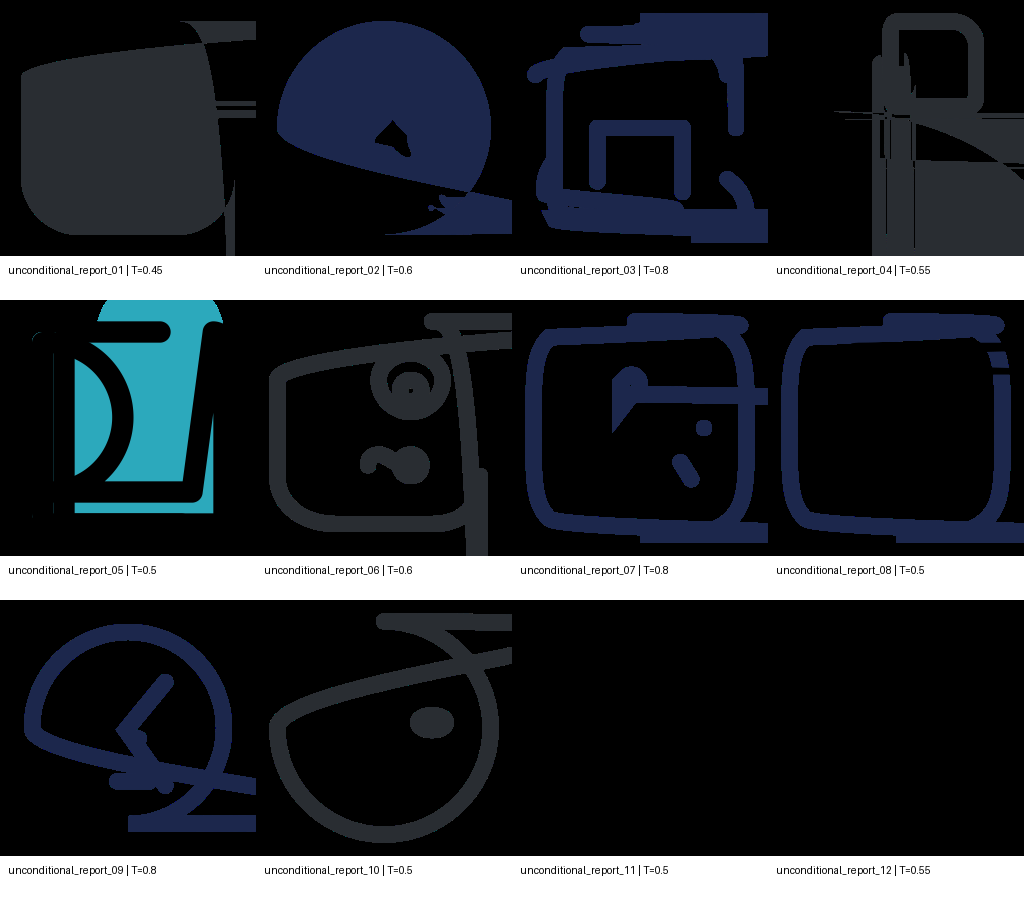

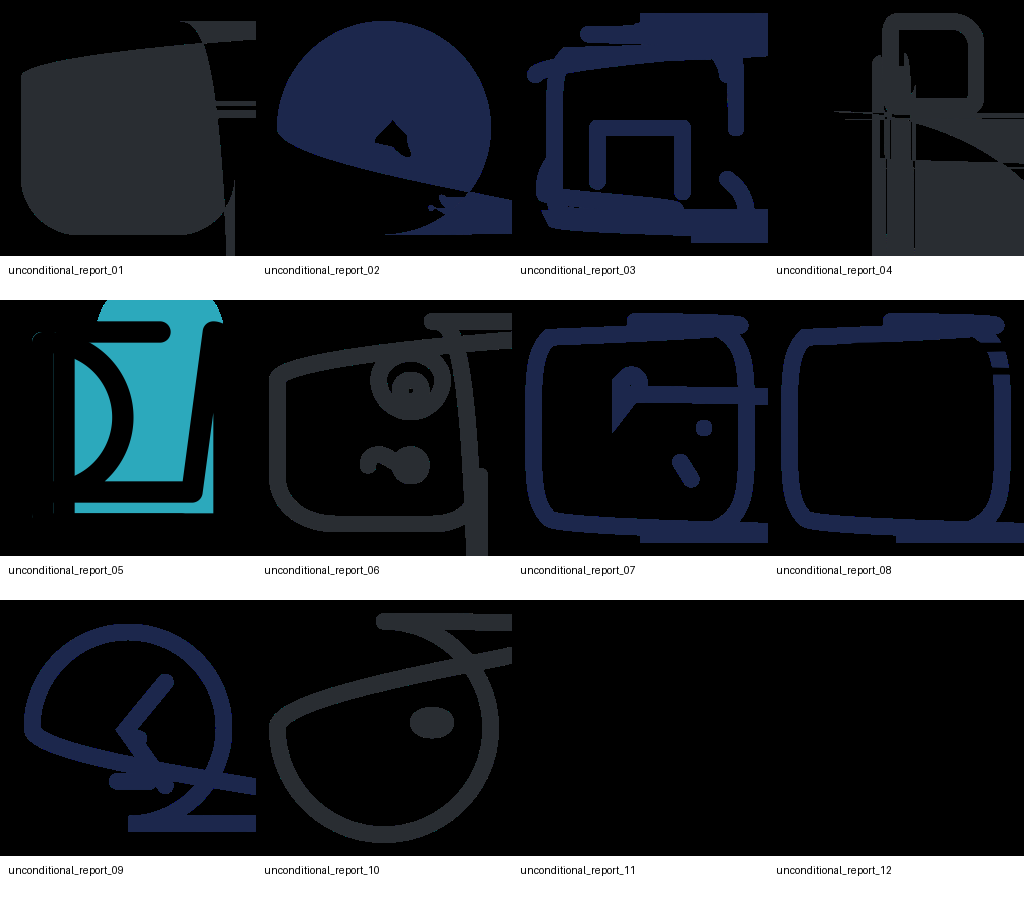

Saved report grids in: /content/drive/MyDrive/svg_gpt_scaling/notebook4_generation_eval/report_assets


In [19]:
def create_image_grid(image_paths, labels, output_path, thumb_size=(256, 256), columns=4):
    items = []
    for path, label in zip(image_paths, labels):
        if path and Path(path).exists():
            items.append((Path(path), label))

    if not items:
        print("No valid images for grid:", output_path)
        return False

    rows = math.ceil(len(items) / columns)
    label_height = 44
    cell_w, cell_h = thumb_size[0], thumb_size[1] + label_height

    grid = Image.new("RGB", (columns * cell_w, rows * cell_h), "white")
    draw = ImageDraw.Draw(grid)

    for idx, (img_path, label) in enumerate(items):
        img = Image.open(img_path).convert("RGB")
        img = ImageOps.contain(img, thumb_size)

        canvas = Image.new("RGB", thumb_size, "white")
        x_offset = (thumb_size[0] - img.width) // 2
        y_offset = (thumb_size[1] - img.height) // 2
        canvas.paste(img, (x_offset, y_offset))

        row = idx // columns
        col = idx % columns
        x = col * cell_w
        y = row * cell_h

        grid.paste(canvas, (x, y))
        draw.text((x + 8, y + thumb_size[1] + 8), label[:38], fill="black")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    grid.save(output_path)
    return True

curated_uncond = df_curated_final[df_curated_final["sample_type"] == "unconditional"].copy() if len(df_curated_final) else pd.DataFrame()
curated_prefix = df_curated_final[df_curated_final["sample_type"] == "prefix_conditioned"].copy() if len(df_curated_final) else pd.DataFrame()

uncond_grid_path = REPORT_ASSETS_DIR / "unconditional_generated_grid_curated.png"
if len(curated_uncond):
    ok = create_image_grid(
        curated_uncond["curated_png_path"].tolist(),
        [f"{r.curated_id} | T={r.temperature}" for r in curated_uncond.itertuples()],
        uncond_grid_path,
        columns=4,
    )
    if ok:
        display(IPyImage(filename=str(uncond_grid_path)))

prefix_grid_path = REPORT_ASSETS_DIR / "prefix_conditioned_generated_grid_curated.png"
if len(curated_prefix):
    ok = create_image_grid(
        curated_prefix["curated_png_path"].tolist(),
        [f"{r.curated_id}" for r in curated_prefix.itertuples()],
        prefix_grid_path,
        columns=3,
    )
    if ok:
        display(IPyImage(filename=str(prefix_grid_path)))

all_grid_path = REPORT_ASSETS_DIR / "all_generated_samples_grid_curated.png"
if len(df_curated_final):
    ok = create_image_grid(
        df_curated_final["curated_png_path"].tolist(),
        [f"{r.curated_id}" for r in df_curated_final.itertuples()],
        all_grid_path,
        columns=4,
    )
    if ok:
        display(IPyImage(filename=str(all_grid_path)))

print("Saved report grids in:", REPORT_ASSETS_DIR)

## 17. Temperature and Prefix Summaries

In [20]:
temperature_summary = (
    uncond_all
    .groupby("temperature")
    .agg(
        num_samples=("sample_id", "count"),
        xml_valid_rate=("xml_valid", "mean"),
        render_rate=("render_ok", "mean"),
        structural_validity_rate=("structural_valid", "mean"),
        report_ready_rate=("report_ready", "mean"),
        avg_visual_score=("visual_score", "mean"),
        avg_dark_fraction=("dark_fraction", "mean"),
        avg_light_fraction=("light_fraction", "mean"),
        avg_non_bg_fraction=("non_bg_fraction", "mean"),
        avg_pixel_std=("pixel_std", "mean"),
    )
    .reset_index()
)
temperature_summary.to_csv(METRICS_DIR / "temperature_summary_unconditional.csv", index=False)
display(temperature_summary)

prefix_summary_rows = []
for item in prefixes:
    prefix_name = item["name"]
    subset = prefix_df[prefix_df["prefix_name"] == prefix_name]
    ready_subset = subset[subset["report_ready"] == True].sort_values("visual_score", ascending=False)
    if len(ready_subset):
        best = ready_subset.iloc[0].to_dict()
        prefix_summary_rows.append({
            "prefix_name": prefix_name,
            "description": item["description"],
            "num_candidates": int(len(subset)),
            "num_report_ready": int(len(ready_subset)),
            "best_candidate_id": best["sample_id"],
            "best_temperature": best["temperature"],
            "best_visual_score": best["visual_score"],
            "best_svg_path": best["svg_path"],
            "best_png_path": best["png_path"],
            "status": "rendered",
        })
    else:
        prefix_summary_rows.append({
            "prefix_name": prefix_name,
            "description": item["description"],
            "num_candidates": int(len(subset)),
            "num_report_ready": 0,
            "best_candidate_id": "",
            "best_temperature": "",
            "best_visual_score": "",
            "best_svg_path": "",
            "best_png_path": "",
            "status": "no report-ready rendered completion",
        })

df_prefix_report = pd.DataFrame(prefix_summary_rows)
df_prefix_report.to_csv(REPORT_ASSETS_DIR / "prefix_completion_report_table.csv", index=False)
display(df_prefix_report)

,temperature,num_samples,xml_valid_rate,render_rate,structural_validity_rate,report_ready_rate,avg_visual_score,avg_dark_fraction,avg_light_fraction,avg_non_bg_fraction,avg_pixel_std
0,0.45,14,0.285714,0.285714,0.285714,0.214286,-713.250903,0.102436,0.744671,0.152775,83.806624
1,0.50,14,0.571429,0.571429,0.571429,0.357143,-427.536721,0.147842,0.732027,0.120104,83.858549
2,0.55,13,0.538462,0.538462,0.538462,0.384615,-460.602206,0.126572,0.794883,0.078535,75.743014
3,0.60,13,0.538462,0.538462,0.538462,0.307692,-460.479320,0.132385,0.751620,0.115965,89.205092
4,0.70,13,0.384615,0.384615,0.384615,0.230769,-614.473573,0.113956,0.874451,0.011560,76.488756
5,0.80,13,0.538462,0.538462,0.538462,0.384615,-460.392589,0.166484,0.692542,0.140928,100.302352


,prefix_name,description,num_candidates,num_report_ready,best_candidate_id,best_temperature,best_visual_score,best_svg_path,best_png_path,status
0,partial_face_one_eye,Partial face: circle face plus one eye.,16,0,,,,,,no report-ready rendered completion
1,open_path_triangle,Open path: triangle-like outline.,16,0,,,,,,no report-ready rendered completion
2,group_with_rect,Group with one rectangle.,16,0,,,,,,no report-ready rendered completion
3,centered_circle_icon,Centered circular icon.,16,0,,,,,,no report-ready rendered completion
4,bar_chart,Partial bar chart.,16,0,,,,,,no report-ready rendered completion


## 18. Save Selected SVG Code Examples and Report Notes

In [21]:
examples_lines = []

for row in df_curated_final.itertuples():
    svg_path = Path(row.curated_svg_path)
    svg_code = svg_path.read_text(encoding="utf-8") if svg_path.exists() else ""
    examples_lines.extend([
        "=" * 100,
        f"Sample: {row.curated_id}",
        f"Type: {row.sample_type}",
        f"Temperature: {row.temperature}",
        f"SVG path: {row.curated_svg_path}",
        f"PNG path: {row.curated_png_path}",
        "",
        svg_code[:3000],
        "",
    ])

examples_text = "\\n".join(examples_lines)
(REPORT_ASSETS_DIR / "selected_generated_svg_code_examples.txt").write_text(examples_text, encoding="utf-8")

report_notes_lines = [
    "Part 4 Summary - Best Model Training and SVG Generation",
    "",
    f"Selected model source: {SELECTED_MODEL_SOURCE}",
    f"Parameter count: {param_count:,}",
    f"Additional training steps: {ADDITIONAL_TRAIN_STEPS}",
    f"Additional tokens seen: {ADDITIONAL_TRAIN_STEPS * tokens_per_step:,}",
    f"Final validation loss: {final_training_metadata['final_val_loss']:.6f}",
    f"Final validation perplexity: {final_training_metadata['final_val_perplexity']:.6f}",
    f"Final test loss: {final_training_metadata['final_test_loss']:.6f}",
    f"Final test perplexity: {final_training_metadata['final_test_perplexity']:.6f}",
    "",
    "Candidate generation setup:",
    f"- Unconditional candidates: {len(uncond_all)}",
    f"- Prefix-conditioned candidates: {len(prefix_all)}",
    f"- Unconditional temperature schedule: {UNCONDITIONAL_TEMPERATURE_SCHEDULE}",
    f"- Prefix temperature schedule: {PREFIX_TEMPERATURE_SCHEDULE}",
    f"- top_k: {TOP_K}",
    f"- top_p: {TOP_P}",
    "",
    "All-candidate quantitative metrics:",
    f"- XML validity rate: {quant_metrics['all_xml_valid_rate']:.4f}",
    f"- SVG render rate: {quant_metrics['all_render_rate']:.4f}",
    f"- Structural validity rate: {quant_metrics['all_structural_validity_rate']:.4f}",
    f"- Report-ready rate: {quant_metrics['all_report_ready_rate']:.4f}",
    "",
    "Curated report samples:",
    f"- Curated unconditional samples: {quant_metrics['num_curated_unconditional_report_samples']}",
    f"- Curated prefix-conditioned samples: {quant_metrics['num_curated_prefix_report_samples']}",
    "",
    "Important reporting note:",
    "- Candidate filtering was used only to choose visually useful examples for figures.",
    "- The quantitative validity/rendering rates are reported over all generated candidates.",
]
report_notes = "\\n".join(report_notes_lines)
(REPORT_ASSETS_DIR / "part4_report_notes.txt").write_text(report_notes, encoding="utf-8")

print(report_notes)
print("Saved report assets in:", REPORT_ASSETS_DIR)

Part 4 Summary - Best Model Training and SVG Generation\n\nSelected model source: standard_large\nParameter count: 33,884,160\nAdditional training steps: 2500\nAdditional tokens seen: 81,920,000\nFinal validation loss: 0.714347\nFinal validation perplexity: 2.042852\nFinal test loss: 0.715334\nFinal test perplexity: 2.044870\n\nCandidate generation setup:\n- Unconditional candidates: 80\n- Prefix-conditioned candidates: 80\n- Unconditional temperature schedule: [0.45, 0.5, 0.55, 0.6, 0.7, 0.8]\n- Prefix temperature schedule: [0.4, 0.45, 0.5, 0.55, 0.6]\n- top_k: 30\n- top_p: 0.9\n\nAll-candidate quantitative metrics:\n- XML validity rate: 0.2812\n- SVG render rate: 0.2812\n- Structural validity rate: 0.2812\n- Report-ready rate: 0.1562\n\nCurated report samples:\n- Curated unconditional samples: 12\n- Curated prefix-conditioned samples: 0\n\nImportant reporting note:\n- Candidate filtering was used only to choose visually useful examples for figures.\n- The quantitative validity/render

In [22]:
print("Author: Naman Singh")

Author: Naman Singh
